In [2]:
#work dir
setwd("/home/mjehangir/telomere-sv-analysis/data/")

In [3]:
# Load necessary libraries
#library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(tibble)
#library(ggridges)
library(tidyverse)


Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://joke

In [4]:
# RTL matrix (assumes tab-delimited, sample IDs as rownames)
all_df <- read.table("SVs_CNVs_TL_combined_for_mixed_model.tsv",
                           sep = "\t",
                           header = TRUE,
                           check.names = FALSE)

In [5]:
head(all_df)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,sv_rate_DEL,sv_rate_DUP,sv_rate_INS,sv_rate_INV,sv_rate_BND,sv_proportion_DEL,sv_proportion_DUP,sv_proportion_INS,sv_proportion_INV,sv_proportion_BND,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2436A,chr1p,5.221000,-0.06948662,0.040306891,0.032245513,0.016122756,0.008061378,0.0000000,0.0010588298,2.745705e-04,3.336604e-05,6.723189e-06,0.000000,NA,NA,NA,NA
2,2436A,chr1q,5.051167,-0.21340301,0.024127575,0.016085050,0.016085050,0.000000000,0.0000000,0.0004908192,2.193438e-04,1.332646e-05,0.000000e+00,0.000000,0.008042525,0.00000000,0.001609727,0.0000000
3,3188,chr1p,1.642500,-2.95775970,0.024184135,0.000000000,0.016122756,0.000000000,0.0000000,0.0000386140,0.000000e+00,5.376939e-06,0.000000e+00,0.000000,0.000000000,0.01612276,0.000000000,0.3678764
4,3188,chr1q,3.086500,0.65675845,0.032170100,0.008042525,0.008042525,0.000000000,0.0000000,0.0004511937,5.141586e-05,2.357264e-05,0.000000e+00,0.000000,0.008042525,0.00000000,0.008048565,0.0000000
5,3988,chr1p,2.347500,-2.53325753,0.072552404,0.000000000,0.024184135,0.008061378,0.0000000,0.0004531865,0.000000e+00,6.876356e-06,6.723189e-06,0.000000,NA,NA,NA,NA
6,3988,chr1q,5.083000,-0.45973091,0.008042525,0.008042525,0.016085050,0.008042525,0.0643402,0.0002589854,5.141586e-05,2.859922e-05,9.618860e-06,1.087534,NA,NA,NA,NA


In [6]:
library(dplyr)
library(lme4)
library(lmerTest)
library(broom.mixed)
library(ggplot2)
library(forcats)

outcome <- "norm_TL"  # or "norm_TL" or "final_average_TL_p75_kb"

# --------------------
# 1) Base prep
# --------------------
df <- all_df %>%
  mutate(
    Sample_ID = factor(Sample_ID),
    chr_arm   = factor(chr_arm)
  )

# If NA means "no CNV called", treat as 0 for BOTH rate and proportion CNVs
df <- df %>%
  mutate(
    cnv_gain_rate = ifelse(is.na(cnv_rate_per_mb_Gain), 0, cnv_rate_per_mb_Gain),
    cnv_loss_rate = ifelse(is.na(cnv_rate_per_mb_Loss), 0, cnv_rate_per_mb_Loss),
    cnv_gain_prop = ifelse(is.na(cnv_proportion_per_mb_Gain), 0, cnv_proportion_per_mb_Gain),
    cnv_loss_prop = ifelse(is.na(cnv_proportion_per_mb_Loss), 0, cnv_proportion_per_mb_Loss)
  ) %>%
  filter(!is.na(.data[[outcome]]))

# --------------------
# 2) SVs or CNVs RATE model
# --------------------
df_rate <- df %>%
  mutate(
    sv_DEL_z  = as.numeric(scale(sv_rate_DEL)),
    sv_DUP_z  = as.numeric(scale(sv_rate_DUP)),
    sv_INS_z  = as.numeric(scale(sv_rate_INS)),
    sv_INV_z  = as.numeric(scale(sv_rate_INV)),
    sv_BND_z  = as.numeric(scale(sv_rate_BND)),
    cnv_gain_z = as.numeric(scale(cnv_gain_rate)),
    cnv_loss_z = as.numeric(scale(cnv_loss_rate))
  )

m_rate <- lmer(
  as.formula(paste0(
    outcome, " ~ ",
    "sv_DEL_z + sv_DUP_z + sv_INS_z + sv_INV_z + sv_BND_z + ",
    "cnv_gain_z + cnv_loss_z + ",
    "(1|Sample_ID)"
  )),
  data = df_rate,
  REML = TRUE
)


Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step


boundary (singular) fit: see help('isSingular')



In [8]:
summary(m_rate)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
as.formula(paste0(outcome, " ~ ", "sv_DEL_z + sv_DUP_z + sv_INS_z + sv_INV_z + sv_BND_z + ",  
    "cnv_gain_z + cnv_loss_z + ", "(1|Sample_ID)"))
   Data: df_rate

REML criterion at convergence: 3107.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.1610 -0.6242 -0.1277  0.4561  5.2912 

Random effects:
 Groups    Name        Variance Std.Dev.
 Sample_ID (Intercept) 0.000    0.000   
 Residual              3.438    1.854   
Number of obs: 758, groups:  Sample_ID, 20

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)   
(Intercept)   0.21428    0.06739 750.00000   3.180  0.00153 **
sv_DEL_z      0.07918    0.07306 750.00000   1.084  0.27882   
sv_DUP_z     -0.12295    0.07709 750.00000  -1.595  0.11115   
sv_INS_z     -0.18947    0.07318 750.00000  -2.589  0.00981 **
sv_INV_z     -0.05375    0.06813 750.00000  -0.789  0.43038   
sv_BND_z      0.08352 

In [12]:
# --------------------
# 3) SV/CNVs PROPORTION model
# --------------------
df_prop <- df %>%
  mutate(
    sv_DEL_z  = as.numeric(scale(sv_proportion_DEL)),
    sv_DUP_z  = as.numeric(scale(sv_proportion_DUP)),
    sv_INS_z  = as.numeric(scale(sv_proportion_INS)),
    sv_INV_z  = as.numeric(scale(sv_proportion_INV)),
    sv_BND_z  = as.numeric(scale(sv_proportion_BND)),
    cnv_gain_z = as.numeric(scale(cnv_gain_prop)),
    cnv_loss_z = as.numeric(scale(cnv_loss_prop))
  )

m_prop <- lmer(
  as.formula(paste0(
    outcome, " ~ ",
    "sv_DEL_z + sv_DUP_z + sv_INS_z + sv_INV_z + sv_BND_z + ",
    "cnv_gain_z + cnv_loss_z + ",
    "(1|Sample_ID)"
  )),
  data = df_prop,
  REML = TRUE
)

boundary (singular) fit: see help('isSingular')



In [13]:
summary(m_prop)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
as.formula(paste0(outcome, " ~ ", "sv_DEL_z + sv_DUP_z + sv_INS_z + sv_INV_z + sv_BND_z + ",  
    "cnv_gain_z + cnv_loss_z + ", "(1|Sample_ID)"))
   Data: df_prop

REML criterion at convergence: 3104.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.0855 -0.6216 -0.1231  0.4763  5.2814 

Random effects:
 Groups    Name        Variance Std.Dev.
 Sample_ID (Intercept) 0.00     0.000   
 Residual              3.43     1.852   
Number of obs: 758, groups:  Sample_ID, 20

Fixed effects:
              Estimate Std. Error         df t value Pr(>|t|)   
(Intercept)   0.214126   0.067304 750.000000   3.181  0.00153 **
sv_DEL_z     -0.187668   0.088746 750.000000  -2.115  0.03479 * 
sv_DUP_z      0.031746   0.092543 750.000000   0.343  0.73166   
sv_INS_z     -0.183911   0.067436 750.000000  -2.727  0.00654 **
sv_INV_z      0.008041   0.067549 750.000000   0.119  0.90528   
sv_BND_z  

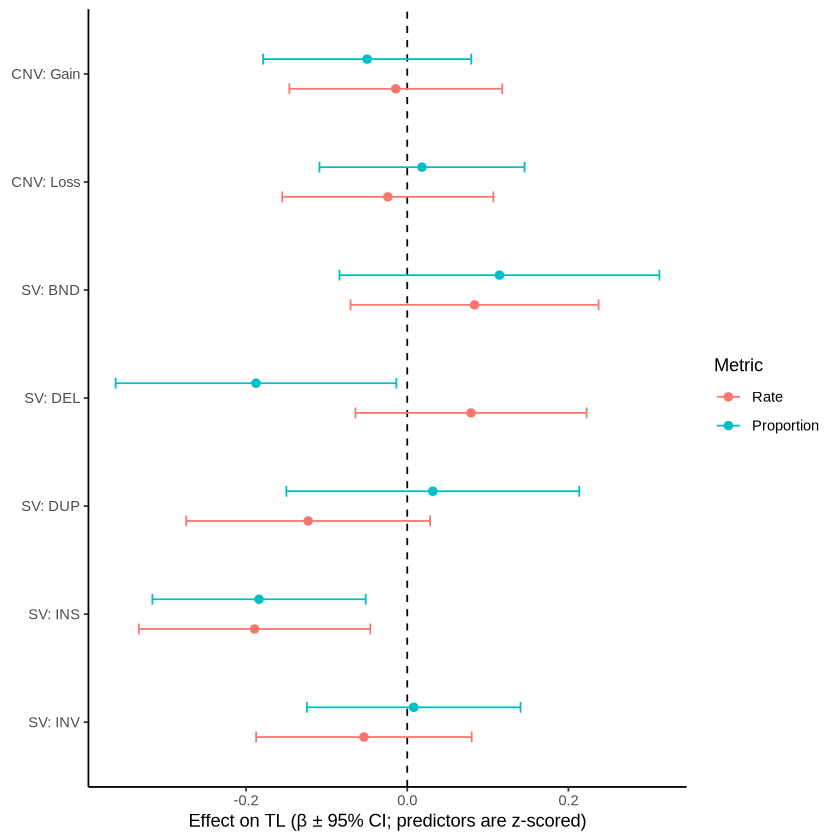

In [55]:
# --------------------
# 4) Tidy + combine for one forest plot
# --------------------
tidy_one <- function(model, metric_label) {
  broom.mixed::tidy(model, effects = "fixed", conf.int = TRUE) %>%
    filter(term != "(Intercept)") %>%
    mutate(
      Metric = metric_label,
      term = recode(term,
        sv_DEL_z    = "SV: DEL",
        sv_DUP_z    = "SV: DUP",
        sv_INS_z    = "SV: INS",
        sv_INV_z    = "SV: INV",
        sv_BND_z    = "SV: BND",
        cnv_gain_z  = "CNV: Gain",
        cnv_loss_z  = "CNV: Loss"
      )
    )
}

coefs_all <- bind_rows(
  tidy_one(m_rate, "Rate"),
  tidy_one(m_prop, "Proportion")
) %>%
  mutate(
    term = fct_rev(factor(term)),
    Metric = factor(Metric, levels = c("Rate", "Proportion"))
  )

# Combined forest: two points per term (Rate vs Proportion)
p_combined <- ggplot(coefs_all, aes(x = estimate, y = term, color = Metric)) +
  geom_vline(xintercept = 0, linetype = 2) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high),
                 height = 0.2,
                 position = position_dodge(width = 0.55)) +
  geom_point(size = 2,
             position = position_dodge(width = 0.55)) +
  labs(x = "Effect on TL (β ± 95% CI; predictors are z-scored)", y = NULL) +
  theme_classic()

p_combined
#ggsave("forest_rate_vs_proportion_combined_AbsTL.pdf", p_combined, width = 8.2, height = 4.6)
#ggsave("forest_rate_vs_proportion_combined_normTL.pdf", p_combined, width = 8.2, height = 4.6)

TELOMERE → INSTABILITY ANALYSIS
TL predictor: norm_TL 
Direction: TL → SV/CNV
Random effects: (1|Sample_ID)+(1|chr_arm) 

Detected SV rate outcomes:
[1] "sv_rate_DEL" "sv_rate_DUP" "sv_rate_INS" "sv_rate_INV" "sv_rate_BND"

Detected SV proportion outcomes:
[1] "sv_proportion_DEL" "sv_proportion_DUP" "sv_proportion_INS"
[4] "sv_proportion_INV" "sv_proportion_BND"

Max duplicate rows per Sample_ID×chr_arm in input: 1 
Rows used: 831 
Patients: 20 
Arms: 44 

Instability outcomes to model (variance > 0):
 [1] "sv_rate_DEL"       "sv_rate_DUP"       "sv_rate_INS"      
 [4] "sv_rate_INV"       "sv_rate_BND"       "sv_proportion_DEL"
 [7] "sv_proportion_DUP" "sv_proportion_INS" "sv_proportion_INV"
[10] "sv_proportion_BND" "cnv_gain_rate"     "cnv_loss_rate"    
[13] "cnv_gain_prop"     "cnv_loss_prop"    

Fitting models: instability ~ TL_z + random effects

  Fitting: sv_rate_DEL ...
    SUCCESS
  Fitting: sv_rate_DUP ...
    SUCCESS
  Fitting: sv_rate_INS ...
    SUCCESS
  Fitting: sv_rat

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 73 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 73 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 73 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 73 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 73 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 73 rows containing missing values or values outside the scale range
(`geom_point()`).”


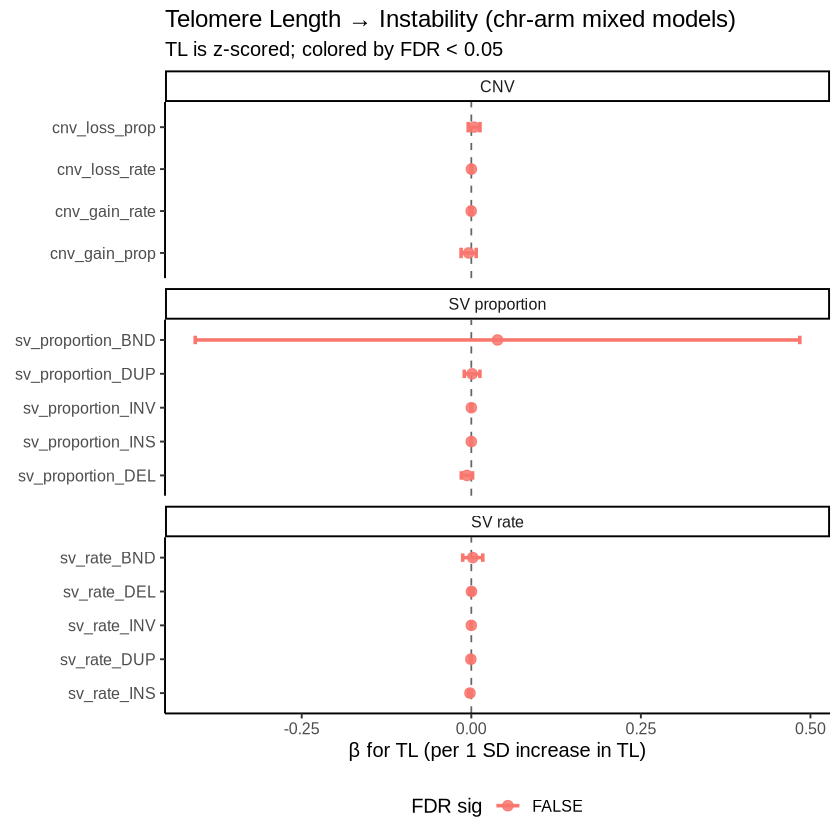


DONE.


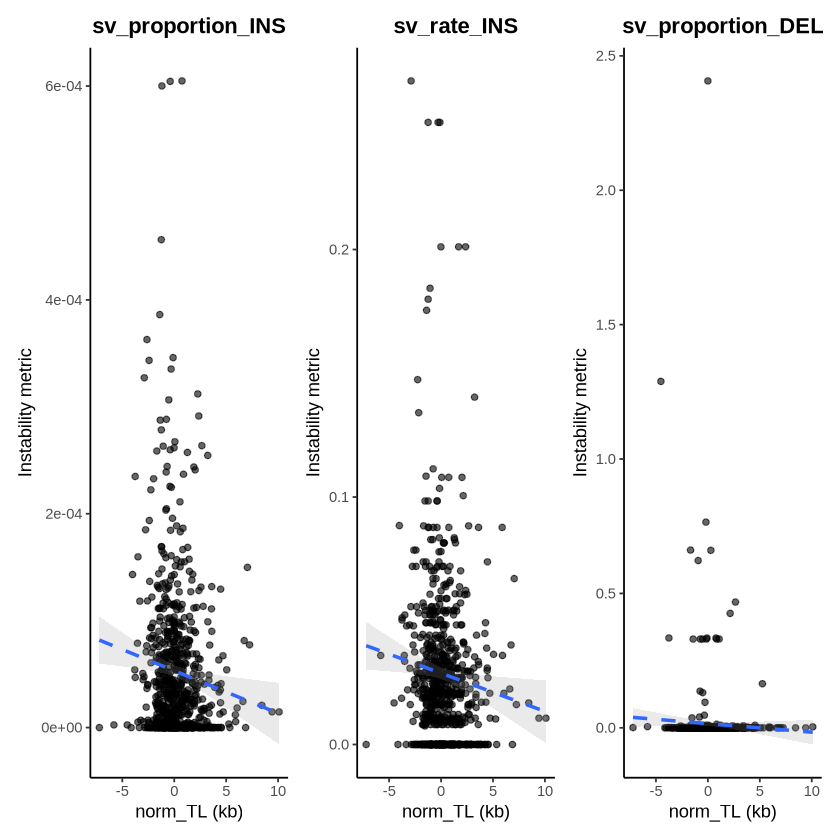

In [8]:
#   - sv_proportion_*
#   - cnv_rate_per_mb_Gain/Loss
#   - cnv_proportion_per_mb_Gain/Loss
# ============================================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(lme4)
  library(ggplot2)
  library(patchwork)
  library(forcats)
})

# -------------------------
# CONFIG
# -------------------------
outcome <- "norm_TL"   # or "norm_TL"
include_chr_arm_RE <- TRUE            # recommended
alpha_fdr <- 0.05

stopifnot(exists("all_df"))

cat("============================================\n")
cat("TELOMERE → INSTABILITY ANALYSIS\n")
cat("============================================\n")
cat("TL predictor:", outcome, "\n")
cat("Direction: TL → SV/CNV\n")
cat("Random effects:", if (include_chr_arm_RE) "(1|Sample_ID)+(1|chr_arm)" else "(1|Sample_ID)", "\n")
cat("============================================\n\n")

# -------------------------
# 1) Prepare data
# -------------------------
req <- c("Sample_ID", "chr_arm", outcome)
miss <- setdiff(req, names(all_df))
if (length(miss) > 0) stop("Missing required columns in all_df: ", paste(miss, collapse=", "))

df0 <- all_df %>%
  mutate(
    Sample_ID = factor(Sample_ID),
    chr_arm   = factor(chr_arm),
    TL_raw    = as.numeric(.data[[outcome]])
  ) %>%
  filter(!is.na(TL_raw))

# Detect predictors
sv_rate_cols <- grep("^sv_rate_", names(df0), value = TRUE)
sv_prop_cols <- grep("^sv_proportion_", names(df0), value = TRUE)

cnv_rate_gain_col <- "cnv_rate_per_mb_Gain"
cnv_rate_loss_col <- "cnv_rate_per_mb_Loss"
cnv_prop_gain_col <- "cnv_proportion_per_mb_Gain"
cnv_prop_loss_col <- "cnv_proportion_per_mb_Loss"

has_cnv_rate_gain <- cnv_rate_gain_col %in% names(df0)
has_cnv_rate_loss <- cnv_rate_loss_col %in% names(df0)
has_cnv_prop_gain <- cnv_prop_gain_col %in% names(df0)
has_cnv_prop_loss <- cnv_prop_loss_col %in% names(df0)

cat("Detected SV rate outcomes:\n"); print(sv_rate_cols)
cat("\nDetected SV proportion outcomes:\n"); print(sv_prop_cols)

if (length(sv_rate_cols) == 0 && length(sv_prop_cols) == 0 &&
    !has_cnv_rate_gain && !has_cnv_rate_loss && !has_cnv_prop_gain && !has_cnv_prop_loss) {
  stop("No SV/CNV outcome columns detected.")
}

# Coerce numeric outcomes + CNV NA->0 (no call)
df0 <- df0 %>%
  mutate(
    across(all_of(c(sv_rate_cols, sv_prop_cols)), ~as.numeric(.x)),
    cnv_gain_rate = if (has_cnv_rate_gain) ifelse(is.na(.data[[cnv_rate_gain_col]]), 0, as.numeric(.data[[cnv_rate_gain_col]])) else NA_real_,
    cnv_loss_rate = if (has_cnv_rate_loss) ifelse(is.na(.data[[cnv_rate_loss_col]]), 0, as.numeric(.data[[cnv_rate_loss_col]])) else NA_real_,
    cnv_gain_prop = if (has_cnv_prop_gain) ifelse(is.na(.data[[cnv_prop_gain_col]]), 0, as.numeric(.data[[cnv_prop_gain_col]])) else NA_real_,
    cnv_loss_prop = if (has_cnv_prop_loss) ifelse(is.na(.data[[cnv_prop_loss_col]]), 0, as.numeric(.data[[cnv_prop_loss_col]])) else NA_real_
  )

# Deduplicate to one row per Sample_ID × chr_arm (mean if duplicates)
num_cols_to_avg <- c(
  "TL_raw",
  sv_rate_cols, sv_prop_cols,
  if (has_cnv_rate_gain) "cnv_gain_rate",
  if (has_cnv_rate_loss) "cnv_loss_rate",
  if (has_cnv_prop_gain) "cnv_gain_prop",
  if (has_cnv_prop_loss) "cnv_loss_prop"
)

dup_check <- df0 %>% count(Sample_ID, chr_arm) %>% summarise(max_n = max(n)) %>% pull(max_n)
cat("\nMax duplicate rows per Sample_ID×chr_arm in input:", dup_check, "\n")

df <- df0 %>%
  group_by(Sample_ID, chr_arm) %>%
  summarise(across(all_of(num_cols_to_avg), ~mean(.x, na.rm = TRUE)), .groups = "drop")

cat("Rows used:", nrow(df), "\n")
cat("Patients:", n_distinct(df$Sample_ID), "\n")
cat("Arms:", n_distinct(df$chr_arm), "\n\n")

# Z-score TL predictor (so beta is per 1 SD TL)
safe_z <- function(x) {
  x <- as.numeric(x)
  if (all(is.na(x))) return(NULL)
  if (sd(x, na.rm = TRUE) == 0) return(NULL)
  as.numeric(scale(x))
}
df$TL_z <- safe_z(df$TL_raw)
if (is.null(df$TL_z)) stop("TL has no variance or is all NA after filtering.")

# -------------------------
# 2) Build outcome list (instability metrics)
# -------------------------
instability_outcomes <- c(sv_rate_cols, sv_prop_cols,
                         if (has_cnv_rate_gain) "cnv_gain_rate",
                         if (has_cnv_rate_loss) "cnv_loss_rate",
                         if (has_cnv_prop_gain) "cnv_gain_prop",
                         if (has_cnv_prop_loss) "cnv_loss_prop")

# Drop outcomes with no variance
instability_outcomes <- instability_outcomes[
  sapply(instability_outcomes, function(nm) sd(df[[nm]], na.rm = TRUE) > 0)
]

cat("Instability outcomes to model (variance > 0):\n")
print(instability_outcomes)
cat("\n")

if (length(instability_outcomes) == 0) stop("No instability outcomes with variance > 0.")

# -------------------------
# 3) Fit univariate mixed models: outcome ~ TL_z + RE
# p-values via Wald z (normal approx)
# -------------------------
rand_str <- if (include_chr_arm_RE) "(1|Sample_ID) + (1|chr_arm)" else "(1|Sample_ID)"

fit_one <- function(ycol) {
  fml <- as.formula(paste0(ycol, " ~ TL_z + ", rand_str))
  m <- lme4::lmer(
    fml, data = df, REML = TRUE,
    control = lme4::lmerControl(optimizer = "bobyqa",
                                check.conv.singular = "ignore")
  )

  b <- lme4::fixef(m)[["TL_z"]]
  V <- as.matrix(vcov(m))
  se <- sqrt(V["TL_z", "TL_z"])
  z  <- b / se
  p  <- 2 * pnorm(abs(z), lower.tail = FALSE)

  tibble(
    family = case_when(
      grepl("^sv_rate_", ycol) ~ "SV rate",
      grepl("^sv_proportion_", ycol) ~ "SV proportion",
      grepl("^cnv_", ycol) ~ "CNV",
      TRUE ~ "Other"
    ),
    outcome_metric = ycol,
    beta_TL = b,              # effect of TL on instability metric
    se = se,
    z_value = z,
    p_value = p,
    singular = lme4::isSingular(m),
    n_obs = nobs(m),
    n_patients = n_distinct(df$Sample_ID)
  )
}

cat("Fitting models: instability ~ TL_z + random effects\n\n")

results_TL_to_instability <- tibble()
for (y in instability_outcomes) {
  cat("  Fitting:", y, "...\n")
  out <- tryCatch(fit_one(y), error = function(e) {
    cat("    ERROR:", e$message, "\n")
    NULL
  })
  if (!is.null(out)) {
    results_TL_to_instability <- bind_rows(results_TL_to_instability, out)
    cat("    SUCCESS\n")
  }
}

if (nrow(results_TL_to_instability) == 0) stop("No models successfully fitted.")

results_TL_to_instability <- results_TL_to_instability %>%
  mutate(
    p_adj_fdr = p.adjust(p_value, method = "fdr"),
    sig_fdr   = p_adj_fdr < alpha_fdr,
    direction = case_when(
      beta_TL < 0 ~ "Longer TL → lower instability",
      beta_TL > 0 ~ "Longer TL → higher instability",
      TRUE ~ "No effect"
    )
  ) %>%
  arrange(p_value)

cat("\n=== TL → INSTABILITY MIXED MODEL RESULTS (sorted by p) ===\n")
print(results_TL_to_instability %>%
        select(family, outcome_metric, beta_TL, se, z_value, p_value, p_adj_fdr, sig_fdr, direction, singular))

# ============================================================================
# PLOTTING (NO SAVING)
# ============================================================================
cat("\n==================================================\n")
cat("PLOTTING\n")
cat("==================================================\n\n")

plot_df <- results_TL_to_instability %>%
  mutate(
    label = outcome_metric,
    ci_lo = beta_TL - 1.96 * se,
    ci_hi = beta_TL + 1.96 * se
  )

p1 <- ggplot(plot_df, aes(x = beta_TL, y = fct_reorder(label, beta_TL))) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray40") +
  geom_errorbarh(aes(xmin = ci_lo, xmax = ci_hi, color = sig_fdr),
                 height = 0.25, linewidth = 1) +
  geom_point(aes(color = sig_fdr, size = sig_fdr), alpha = 0.85) +
  scale_size_manual(values = c(`TRUE` = 4, `FALSE` = 2.6)) +
  facet_wrap(~family, scales = "free_y", ncol = 1) +
  labs(
    title = "Telomere Length → Instability (chr-arm mixed models)",
    subtitle = paste0("TL is z-scored; colored by FDR < ", alpha_fdr),
    x = "β for TL (per 1 SD increase in TL)",
    y = NULL,
    color = "FDR sig",
    size = "FDR sig"
  ) +
  theme_classic(base_size = 12) +
  theme(legend.position = "bottom")

print(p1)

# Optional: show top nominal hits as arm-level scatter (patient-colored not included)
top3 <- results_TL_to_instability %>% arrange(p_value) %>% head(3)
if (nrow(top3) > 0) {
  scatters <- lapply(top3$outcome_metric, function(ycol) {
    ggplot(df, aes(x = TL_raw, y = .data[[ycol]])) +
      geom_point(alpha = 0.6) +
      geom_smooth(method = "lm", se = TRUE, linetype = "dashed", alpha = 0.2) +
      labs(title = ycol, x = paste0(outcome, " (kb)"), y = "Instability metric") +
      theme_classic(base_size = 11) +
      theme(plot.title = element_text(face = "bold", hjust = 0.5))
  })
  p2 <- Reduce(`|`, scatters)
  print(p2)
}

cat("\nDONE.\n")
